# CIFAR-10 이미지 분류 - CNN, Optimizer 비교

CIFAR-10(32x32 컬러 이미지, 10개 클래스)에 CNN(Conv2D + MaxPooling2D 기반)을 적용하고,
같은 모델 구조에서 optimizer만 `adam`과 `adadelta`로 바꿔가며 20 epoch씩 비교한 노트북입니다.

- **Dataset**: `keras.datasets.cifar10` — 32x32 컬러 이미지, 10개 클래스(비행기/자동차/새/고양이 등), train 5만 장 / test 1만 장
- **모델**: Conv2D(32) → MaxPool → Conv2D(64) → MaxPool → Dropout(0.25) → Flatten → Dense(128) → Dense(10, softmax)
- **다루는 내용**: CNN 기본 구조 구현, optimizer 비교(Adam vs Adadelta), 예측 성공/실패 샘플 시각화

> 아래 학습 로그(20 epoch)와 그래프는 실제로 학습을 돌려서 나온 결과를 그대로 담았습니다.


## 0. 함수 정의
데이터 로드/정규화, 모델 생성, 학습 곡선/예측 결과 시각화 함수를 정의한다.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt
import numpy as np
import random
import time


def load_data():
    (X_train_full, y_train_full), (X_test, y_test) = cifar10.load_data()
    X_train_full = X_train_full.astype(np.float32)
    X_test = X_test.astype(np.float32)
    return X_train_full, y_train_full, X_test, y_test


def data_normalization(X_train_full, X_test):
    """0~255 픽셀값을 0~1로 정규화한다."""
    X_train_full = X_train_full / 255.0
    X_test = X_test / 255.0
    print(X_train_full.shape)
    print(X_test.shape)
    return X_train_full, X_test


def makemodel(X_train, y_train, X_valid, y_valid, optimizer, epochs):
    """Conv2D x2 + MaxPooling x2 + Dropout 구조의 CNN.
    optimizer를 인자로 받아 'adam'/'adadelta' 등 다른 옵티마이저를 바꿔가며 비교 실험할 수 있게 했다."""
    model = Sequential()
    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)))
    model.add(MaxPooling2D(pool_size=2))

    model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=2))
    model.add(Dropout(0.25))

    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(10, activation='softmax'))

    model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

    tb_hist = keras.callbacks.TensorBoard(log_dir='./graph', histogram_freq=0, write_graph=True, write_images=True)
    start = time.time()
    # 참고: 별도 validation split을 만들지 않고 X_test/y_test를 그대로 validation_data로 사용했다
    # (원본 실습 코드 그대로 유지 — 정석적으로는 train에서 validation set을 따로 떼는 것이 바람직하다)
    history = model.fit(X_train, y_train, epochs=epochs,
                         validation_data=(X_valid, y_valid), callbacks=[tb_hist])
    print("time :", time.time() - start)
    return model, history


def plot_history(histories, key='accuracy'):
    plt.figure(figsize=(16, 10))
    for name, history in histories:
        val = plt.plot(history.epoch, history.history['val_' + key], '--', label=name.title() + ' Val')
        plt.plot(history.epoch, history.history[key], color=val[0].get_color(), label=name.title() + ' Train')
    plt.xlabel('Epochs')
    plt.ylabel(key.replace('_', ' ').title())
    plt.legend()
    plt.xlim([0, max(history.epoch)])
    plt.show()


def draw_prediction(indices, k, X_test, y_test, yhat, cmap):
    """맞춘/틀린 샘플 인덱스 목록(indices)에서 k개를 뽑아 이미지 그리드로 보여준다."""
    samples = random.choices(population=indices, k=k)
    plt.figure(figsize=(12, 8))
    for count, n in enumerate(samples, start=1):
        plt.subplot(4, 4, count)
        plt.imshow(X_test[n].reshape(32, 32, 3), cmap=cmap, interpolation='nearest')
        plt.title(f"Label:{y_test[n]}, Prediction:{yhat[n]}")
    plt.tight_layout()
    plt.show()


def evalmodel(X_test, y_test, model, cmap):
    """예측 후 맞은 샘플 16개, 틀린 샘플 16개를 각각 이미지로 시각화한다."""
    yhat = model.predict(X_test)
    yhat = yhat.argmax(axis=1)
    print(yhat.shape)

    correct = [n for n in range(len(y_test)) if yhat[n] == y_test[n]]
    wrong = [n for n in range(len(y_test)) if yhat[n] != y_test[n]]

    draw_prediction(correct, 16, X_test, y_test, yhat, cmap)
    draw_prediction(wrong, 16, X_test, y_test, yhat, cmap)


## 1. 데이터 로드

In [2]:
X_train, y_train, X_test, y_test = load_data()

## 2. 데이터 정규화

In [3]:
X_train, X_test = data_normalization(X_train,  X_test)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


## 3. 실험 1 — Optimizer: Adam

20 epoch 학습 후, 예측에 성공한 샘플/실패한 샘플을 각각 이미지로 확인하고 학습 곡선을 그린다.

Epoch 1/20
1563/1563 [==============================] - 29s 18ms/step - loss: 1.4823 - accuracy: 0.4655 - val_loss: 1.2030 - val_accuracy: 0.5761
Epoch 2/20
1563/1563 [==============================] - 30s 19ms/step - loss: 1.1343 - accuracy: 0.5991 - val_loss: 1.0414 - val_accuracy: 0.6422
Epoch 3/20
1563/1563 [==============================] - 31s 20ms/step - loss: 1.0094 - accuracy: 0.6460 - val_loss: 0.9645 - val_accuracy: 0.6607
Epoch 4/20
1563/1563 [==============================] - 32s 20ms/step - loss: 0.9254 - accuracy: 0.6764 - val_loss: 0.9038 - val_accuracy: 0.6831
Epoch 5/20
1563/1563 [==============================] - 38s 24ms/step - loss: 0.8496 - accuracy: 0.7015 - val_loss: 0.9596 - val_accuracy: 0.6740
Epoch 6/20
1563/1563 [==============================] - 34s 22ms/step - loss: 0.7993 - accuracy: 0.7191 - val_loss: 0.8600 - val_accuracy: 0.7007
Epoch 7/20
1563/1563 [==============================] - 32s 20ms/step - loss: 0.7422 - accuracy: 0.7404 - val_loss: 0.8352 -

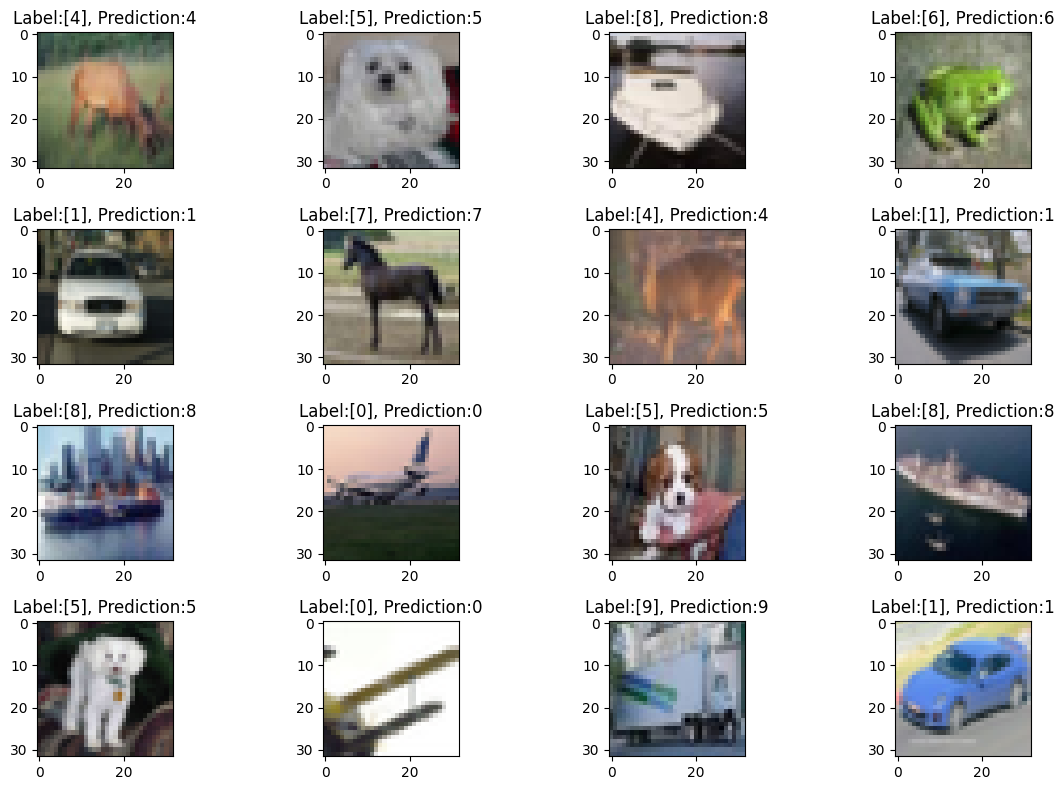

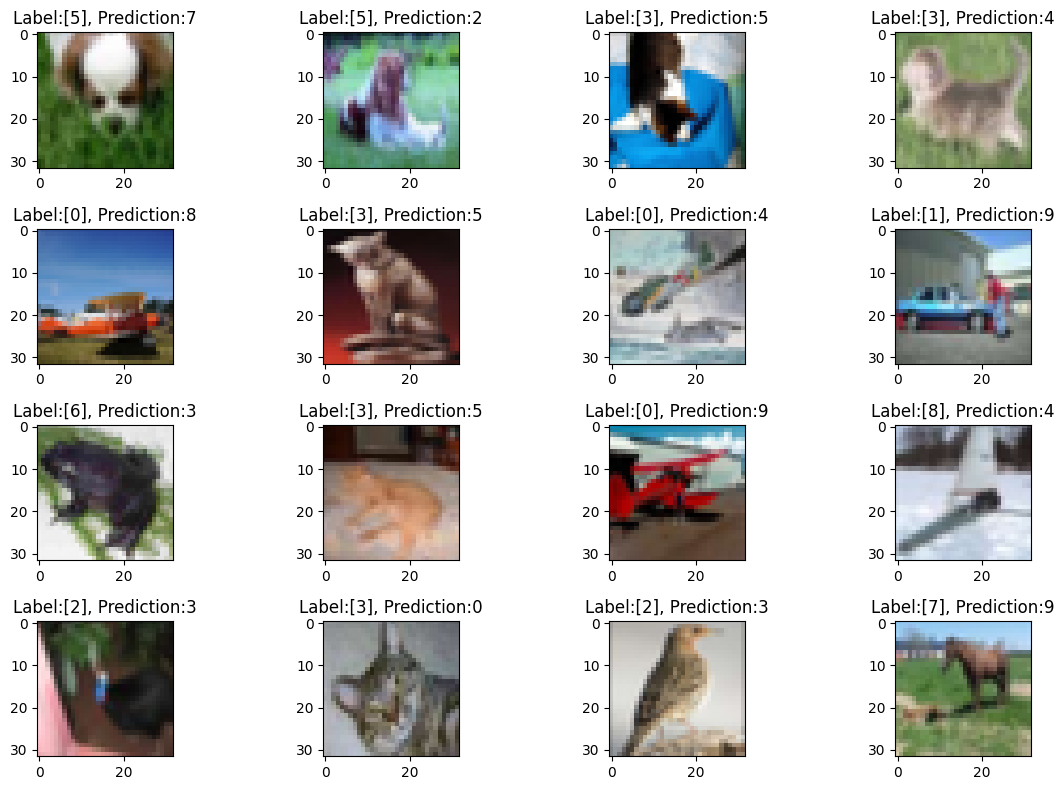

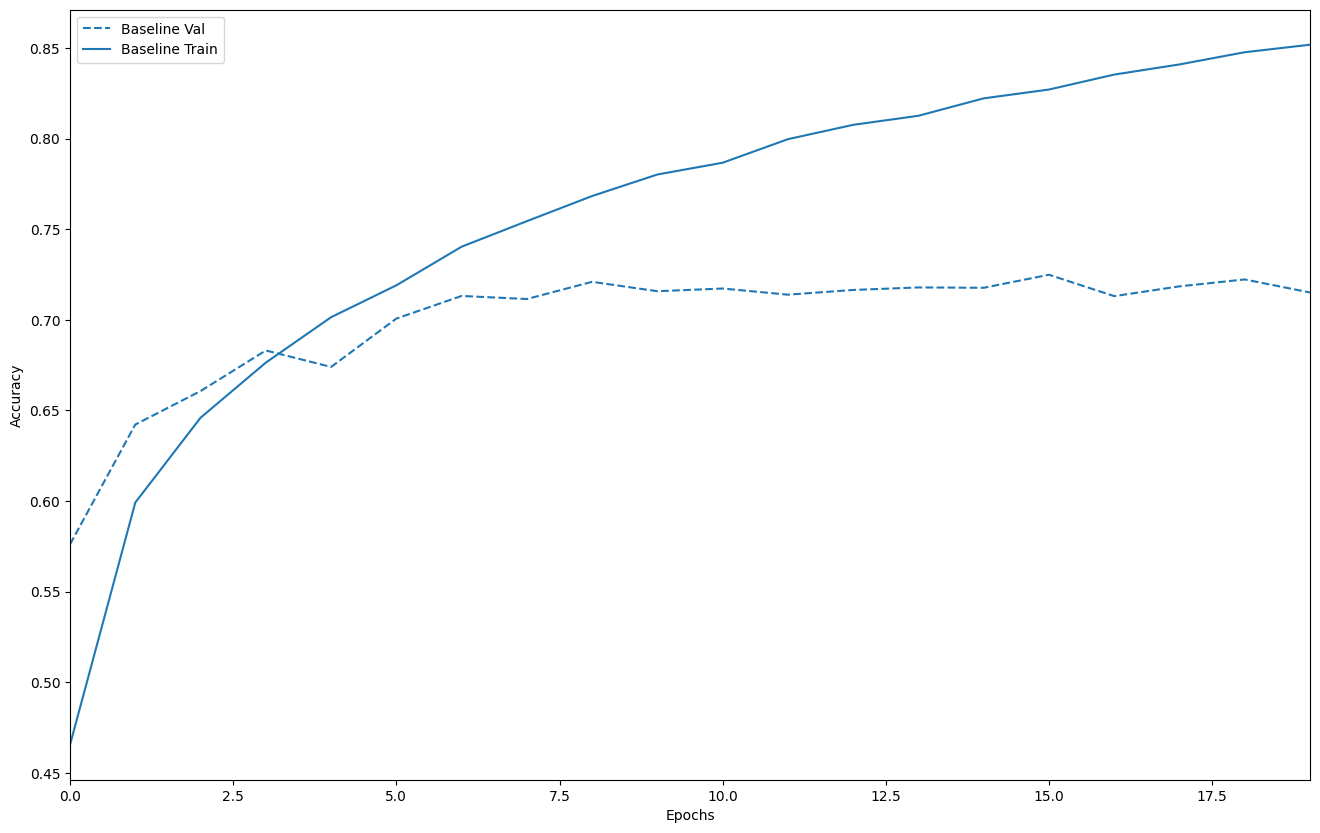

In [4]:
model, history = makemodel(X_train, y_train, X_test, y_test,'adam', epochs=20)

evalmodel(X_test, y_test, model, cmap='Pastel1')  
plot_history([('baseline', history)])

## 4. 실험 2 — Optimizer: Adadelta

동일한 모델 구조, 동일한 20 epoch, optimizer만 `adadelta`로 바꿔서 다시 학습한다.

Epoch 1/20
1563/1563 [==============================] - 37s 23ms/step - loss: 2.3040 - accuracy: 0.1087 - val_loss: 2.2920 - val_accuracy: 0.1224
Epoch 2/20
1563/1563 [==============================] - 45s 28ms/step - loss: 2.2902 - accuracy: 0.1301 - val_loss: 2.2803 - val_accuracy: 0.1471
Epoch 3/20
1563/1563 [==============================] - 36s 23ms/step - loss: 2.2801 - accuracy: 0.1489 - val_loss: 2.2697 - val_accuracy: 0.1692
Epoch 4/20
1563/1563 [==============================] - 32s 21ms/step - loss: 2.2694 - accuracy: 0.1639 - val_loss: 2.2582 - val_accuracy: 0.1916
Epoch 5/20
1563/1563 [==============================] - 35s 23ms/step - loss: 2.2587 - accuracy: 0.1787 - val_loss: 2.2454 - val_accuracy: 0.2039
Epoch 6/20
1563/1563 [==============================] - 41s 26ms/step - loss: 2.2461 - accuracy: 0.1912 - val_loss: 2.2304 - val_accuracy: 0.2163
Epoch 7/20
1563/1563 [==============================] - 41s 26ms/step - loss: 2.2320 - accuracy: 0.2004 - val_loss: 2.2134 -

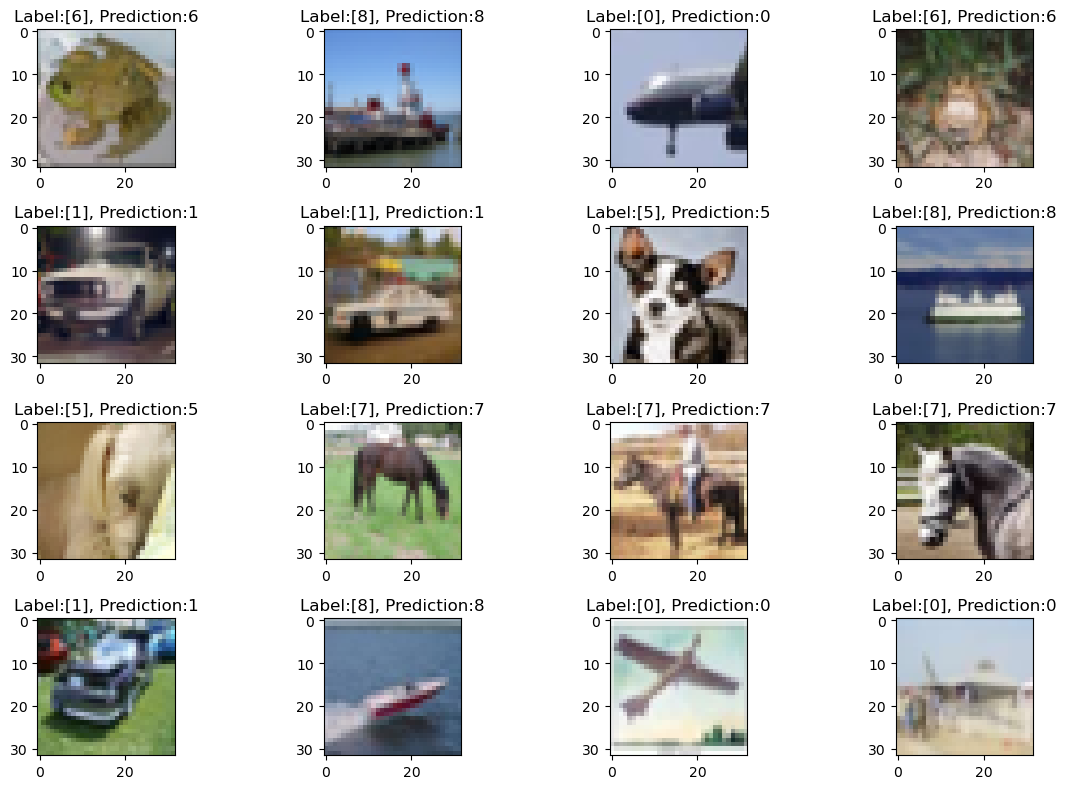

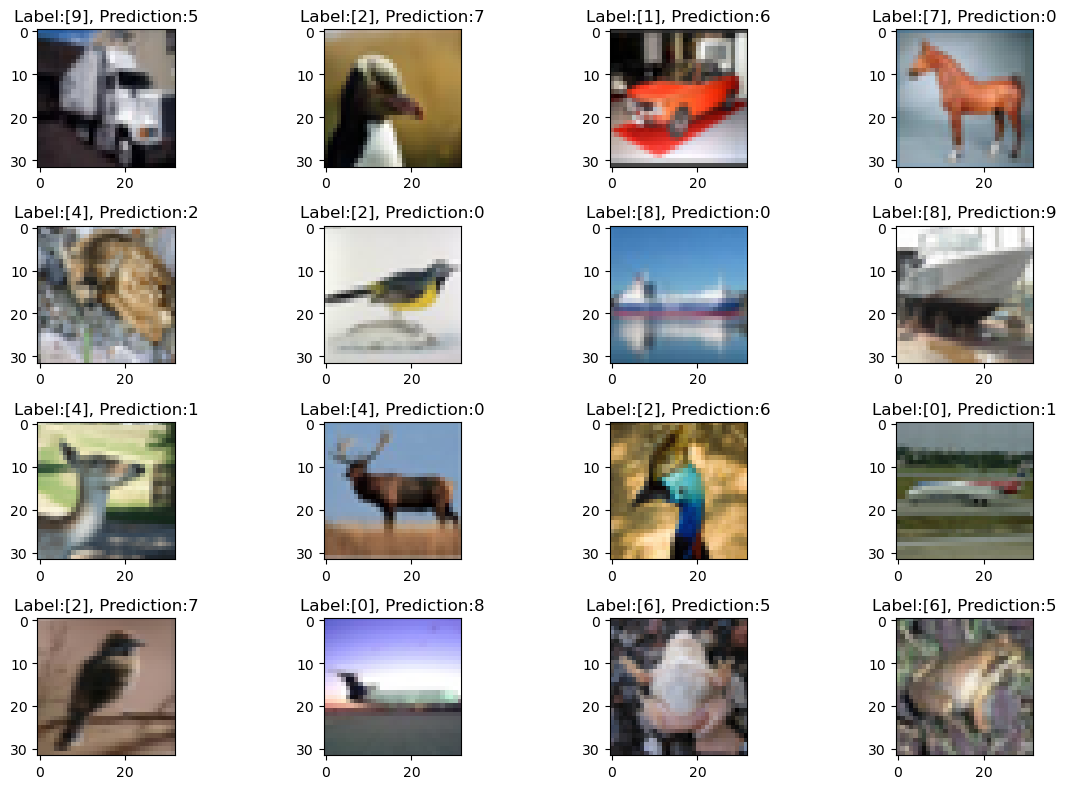

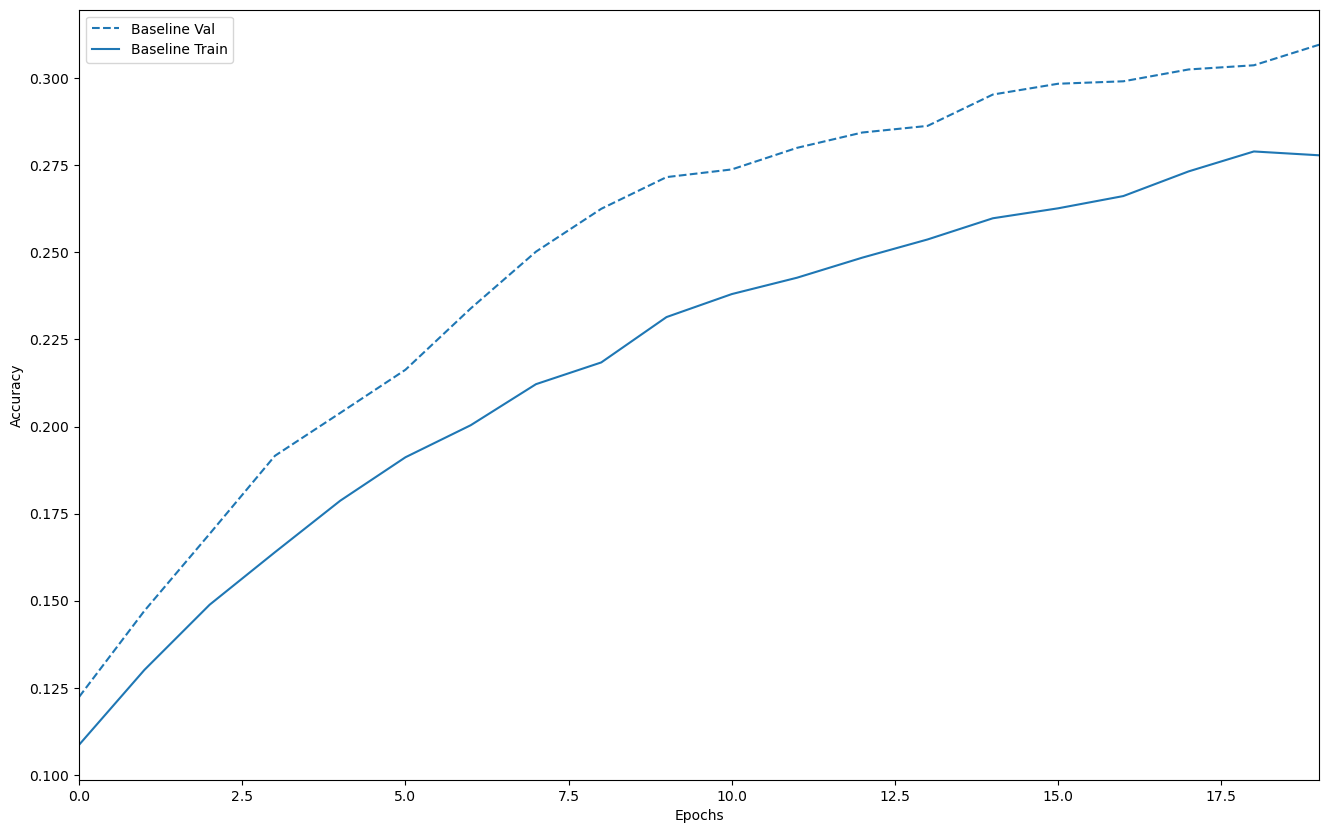

In [5]:
model, history = makemodel(X_train, y_train, X_test, y_test,'adadelta', epochs=20)

evalmodel(X_test, y_test, model, cmap='Pastel1')  
plot_history([('baseline', history)])

## 결과 및 배운 점

**최종 validation accuracy(20 epoch 기준)**: Adam 0.7205 vs Adadelta 0.3096 — **Adam이 압도적으로 우수했다.**

- Adam은 20 epoch 안에 val_accuracy 72%까지 비교적 빠르게 올라간 반면, Adadelta는 같은 20 epoch 동안 31% 수준에서 멈췄다.
  Adadelta는 학습률을 적응적으로 아주 조금씩만 줄여나가는 방식이라, 초기 학습률·epoch 수 설정에 따라 Adam보다 수렴이
  훨씬 느릴 수 있다는 것을 결과로 확인했다 (Adadelta 자체가 나쁜 optimizer라기보다, 이 설정·epoch 수에서는 불리했다는 의미).
- 예측 성공/실패 이미지를 직접 눈으로 비교해보면, 실패 샘플들은 배경이 복잡하거나 클래스 간 생김새가 비슷한 경우
  (예: 고양이/개, 트럭/자동차)가 많았다 — 32x32의 작은 컬러 이미지에서는 세밀한 특징을 구분하기가 쉽지 않다는 것을 체감할 수 있었다.
- MNIST(흑백, 단순한 배경)보다 CIFAR-10(컬러, 복잡한 배경)에서 CNN 학습이 훨씬 더 어렵고 느리다는 것도 실습을 통해 확인했다.
